# Conociendo nuestros datos de pingüinos. 🗺🧭🐧

## Instalar librerías necesarias

```
!pip install --upgrade pip
!pip install palmerpenguins==0.1.4 numpy==1.23.4 pandas==1.5.1 seaborn==0.12.1 matplotlib==3.6.0 empiricaldist==0.6.7 statsmodels==0.13.5 scikit-learn==1.1.2 pyjanitor==0.23.1 session-info
```

## Importar librerías

In [96]:
# import janitor
# import palmerpenguins

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats  # for t-test
import sklearn.metrics  # for confusion matrix

import empiricaldist  # for CDF


# import scipy stats
import scipy.stats as stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats as ss
# import session_info  # for session info

## Establecer apariencia general de los gráficos

In [97]:
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

penguin_color = {
    'Adelie': '#ff6602ff',
    'Gentoo': '#0f7175ff',
    'Chinstrap': '#c65dc9ff'
}

## Cargar los datos

### Utilizando el paquete `palmerpenguins`

#### Datos crudos

In [98]:
# penguins_df: pd.DataFrame = palmerpenguins.load_penguins_raw()  # load the raw data
# penguins_df

#### Datos previamente procesados

In [99]:
# processed_df: pd.DataFrame = palmerpenguins.load_penguins()
# processed_df

### Utilizando los conjuntos de datos de `seaborn`

In [100]:
df: pd.DataFrame = sns.load_dataset('penguins')

### Utilizando la interfaz de `Deepnote`

Links de importación de datos:

- [Conjunto de datos crudos](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins_raw.csv).
- [Conjunto de datos previamente procesados](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv).

# Colecta y validación de datos

In [101]:
# data: pd.DataFrame = pd.read_csv('penguins.csv')

## ¿Qué tipo de dato son las variables del conjunto de datos?

In [102]:
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

## ¿Cuántas variables de cada tipo de dato tenemos en el conjunto de datos?

In [103]:
df.dtypes.value_counts()

float64    4
object     3
dtype: int64

## ¿Cuántas variables y observaciones tenemos en el conjunto de datos?

In [104]:
df.shape

(344, 7)

## ¿Existen valores nulos explícitos en el conjunto de datos?

In [105]:
df.isnull().any()

species              False
island               False
bill_length_mm        True
bill_depth_mm         True
flipper_length_mm     True
body_mass_g           True
sex                   True
dtype: bool

## De tener observaciones con valores nulos, ¿cuántas tenemos por cada variable?

In [106]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## ¿Cuántos valores nulos tenemos en total en el conjunto de datos?

In [107]:
df.isnull().sum().sum()

19

## ¿Cuál es la proporción de valores nulos por cada variable?

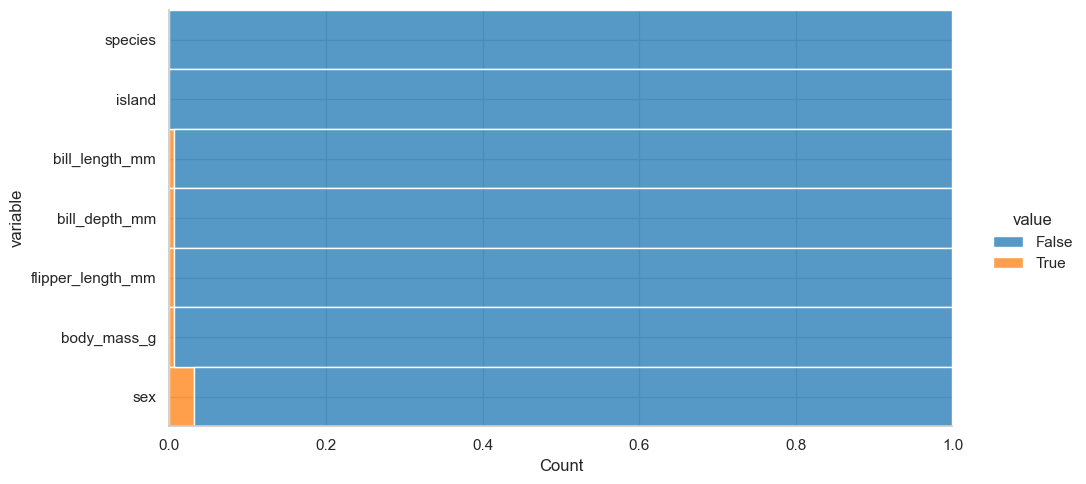

In [108]:
df.isnull().melt().pipe(
    lambda df: (
        sns.displot(
            data=df,
            y='variable',
            hue='value',
            multiple='fill',
            aspect=2
        )
    )
)

## ¿Cómo podemos visualizar los valores nulos en todo el conjunto de datos?

<AxesSubplot: >

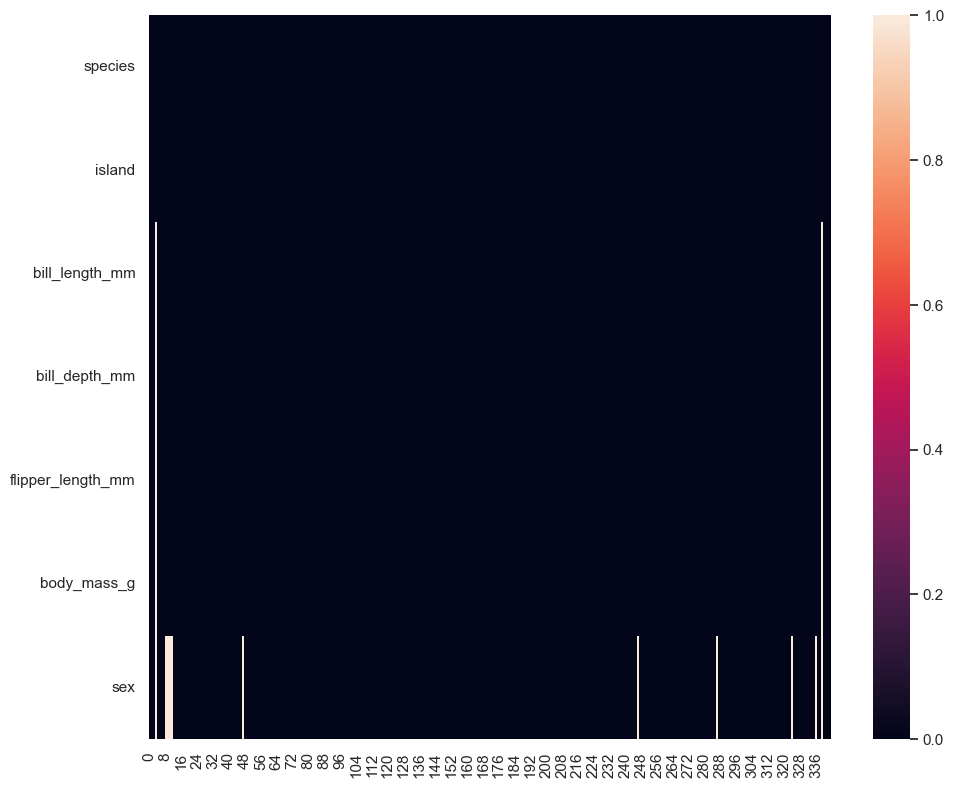

In [109]:
df.isnull().transpose().pipe(lambda df: (sns.heatmap(data=df)))  # heatmap

## ¿Cuántas observaciones perdemos si eliminamos los datos faltantes?

Se eliminarán 11 filas
Ahora hay 333 filas


<AxesSubplot: >

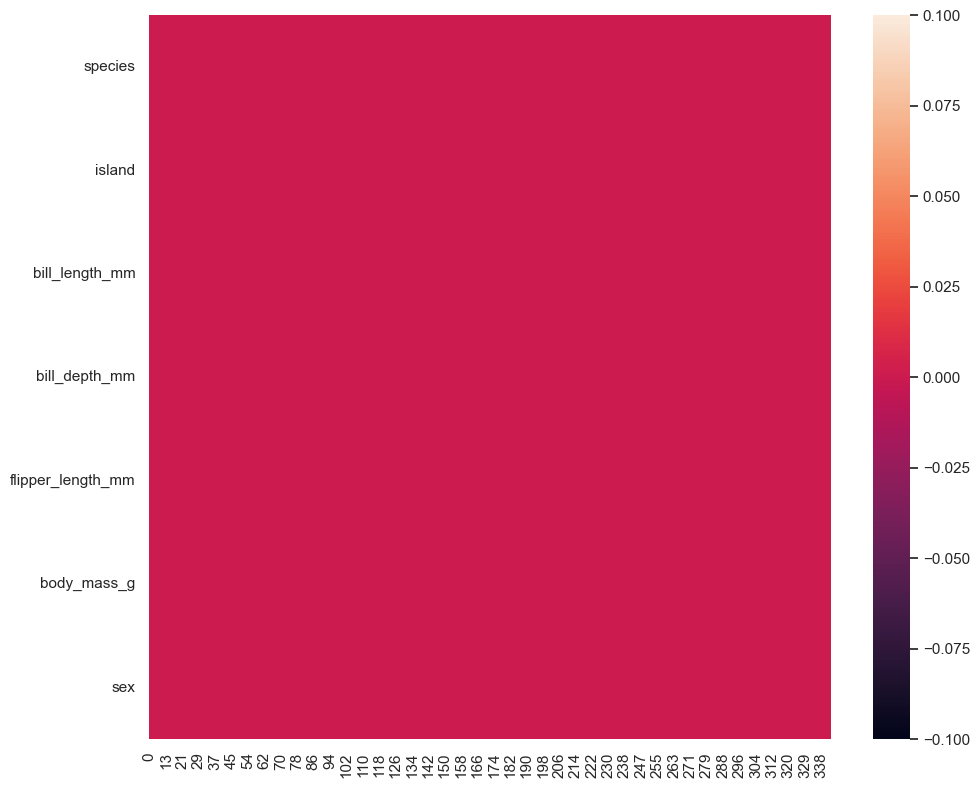

In [110]:
print(f'Se eliminarán {df.shape[0] - df.dropna().shape[0]} filas')
df = df.dropna()  # drop rows with missing values
print(f'Ahora hay {df.shape[0]} filas')  # 333
df.isnull().transpose().pipe(lambda df: (sns.heatmap(data=df)))  # heatmap

# Conteos y proporciones

## Preludio: ¿Qué estadísticos describen el conjunto de datos?

### Todas las variables

In [111]:
df.describe(include='all')  # summary statistics (all columns)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,333,333,333.000000,333.000000,333.000000,333.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,Male
freq,146,163,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.992793,17.164865,200.966967,4207.057057,NaN
std,NaN,NaN,5.468668,1.969235,14.015765,805.215802,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.500000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.500000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.600000,18.700000,213.000000,4775.000000,NaN


### Solo las numéricas

In [112]:
df.describe(include=[np.number])  # numeric columns

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


### Solo categóricas - 1

In [113]:
df.describe(include=[object])  # categorical columns

,species,island,sex
count,333,333,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,146,163,168


### Solo categóricas - 2

In [114]:
df.astype({
    'species': 'category',
    'island': 'category',
    'sex': 'category'
    }).describe(include=['category'])  # categorical columns

,species,island,sex
count,333,333,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,146,163,168


## ¿Cómo visualizar los conteos?

### Pandas

<AxesSubplot: >

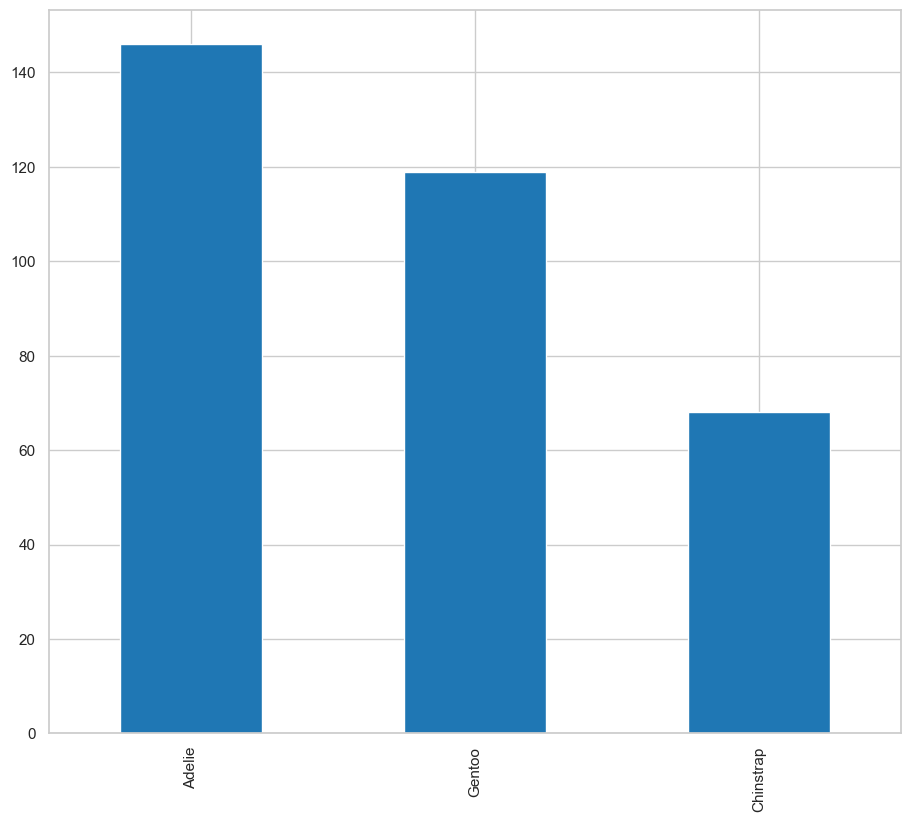

In [115]:
df['species'].value_counts().plot(kind='bar')  # count of each category

### Seaborn

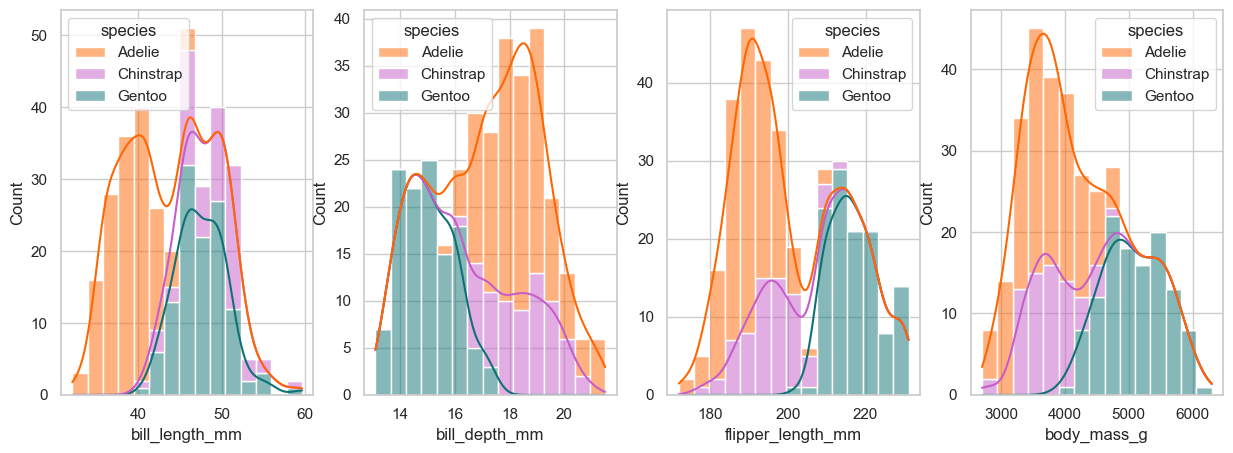

In [116]:
numeric_columns = df.select_dtypes(include=np.number).columns  # type: ignore
fig,ax = plt.subplots(1,len(numeric_columns), figsize=(15,5))

for i in range(len(numeric_columns)):
    sns.histplot( 
        ax=ax[i],
        data=df,
        x=numeric_columns[i],
        multiple='stack',
        hue='species',
        bins=15,  # type: ignore
        palette=penguin_color,
        kde=True,
        )

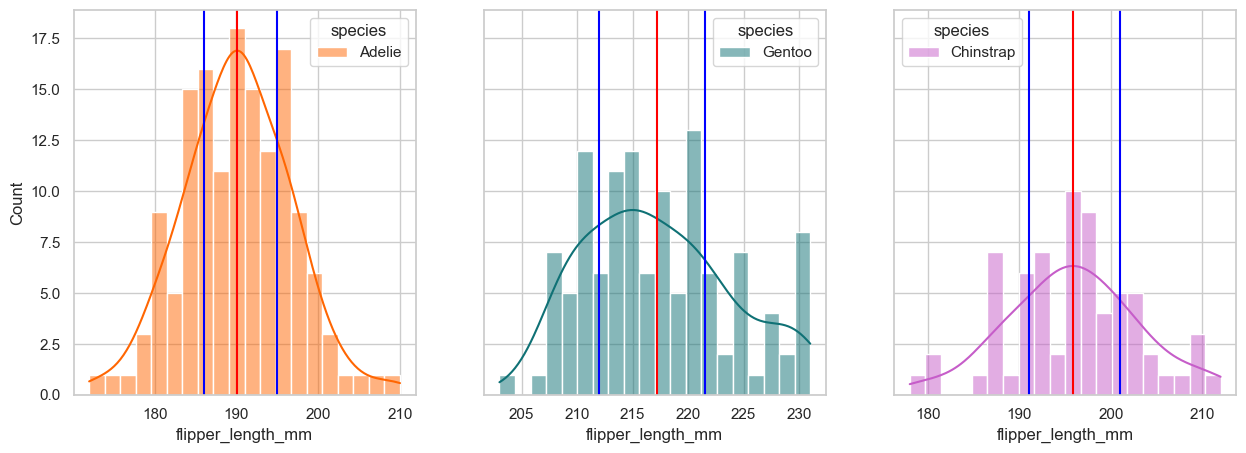

In [117]:
species = df.species.unique()

adelie_df = df.query("species == 'Adelie'")
gentoo_df = df.query("species == 'Gentoo'")
chinstrap_df = df.query("species == 'Chinstrap'")

list = [adelie_df,gentoo_df,chinstrap_df]

fig,ax = plt.subplots(1,len(list), figsize=(15,5), sharey=True)

for i in range(len(list)):
    sns.histplot( 
        ax=ax[i],
        data=list[i],
        x='flipper_length_mm',
        multiple='layer',
        hue='species',
        bins=20,  # type: ignore
        kde=True,
        palette=penguin_color,
        )
    ax[i].axvline(x=list[i]['flipper_length_mm'].mean(), color='red')
    ax[i].axvline(x=list[i]['flipper_length_mm'].quantile(.25), color='blue')
    ax[i].axvline(x=list[i]['flipper_length_mm'].quantile(.75), color='blue')

<AxesSubplot: xlabel='species', ylabel='count'>

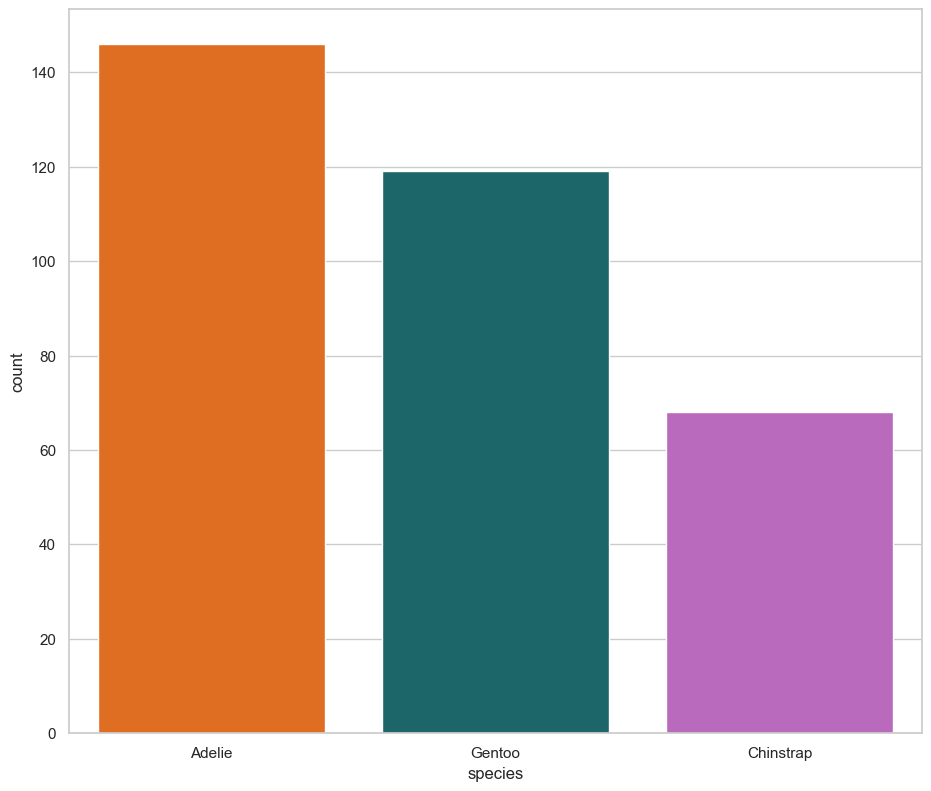

In [118]:
df.value_counts('species', sort=True).reset_index(name='count').pipe(
    lambda df: (sns.barplot(data=df, x='species', y='count', palette=penguin_color)))

([<matplotlib.patches.Wedge at 0x211e8464850>,
 [Text(1.0794918034059888, 0.21141770592664766, 'Adelie'),
  Text(-0.7383543653463893, -0.8153728172890795, 'Gentoo'),
  Text(-0.6582609880919551, 0.8813015780969663, 'Chinstrap')],
 [Text(0.588813710948721, 0.11531874868726234, '43.8%'),
  Text(-0.40273874473439414, -0.444748809430407, '35.7%'),
  Text(-0.35905144805015726, 0.48070995168925423, '20.4%')])

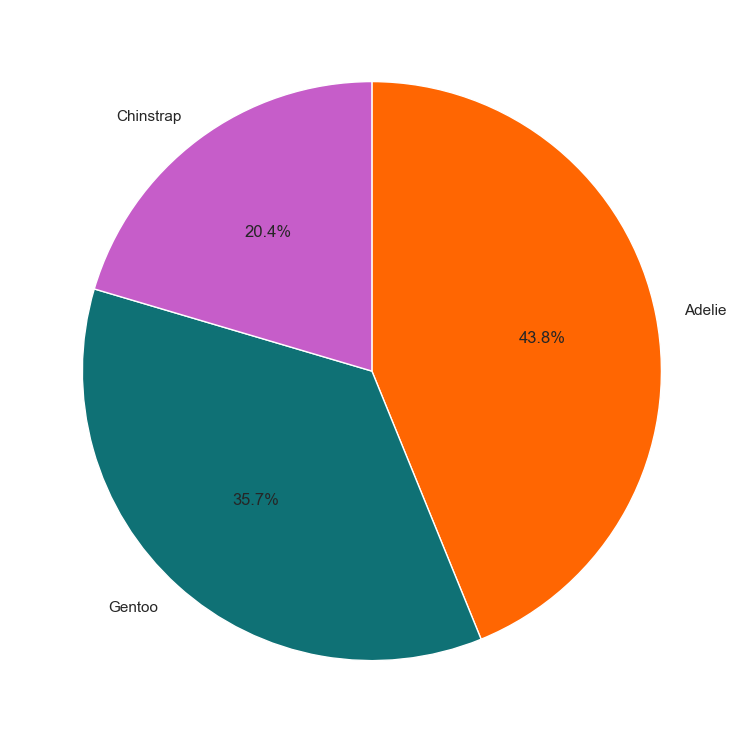

In [119]:
# print proportions in a pie chart
plt.pie(
    x=df['species'].value_counts(),
    labels=df['species'].value_counts().index,  # type: ignore
    autopct='%1.1f%%',  # set the percentage format
    colors=penguin_color.values(),  # type: ignore
    startangle=90,  # rotate the chart
    counterclock=False,  # rotate the chart
)

### ¿Cómo visualizar las proporciones?

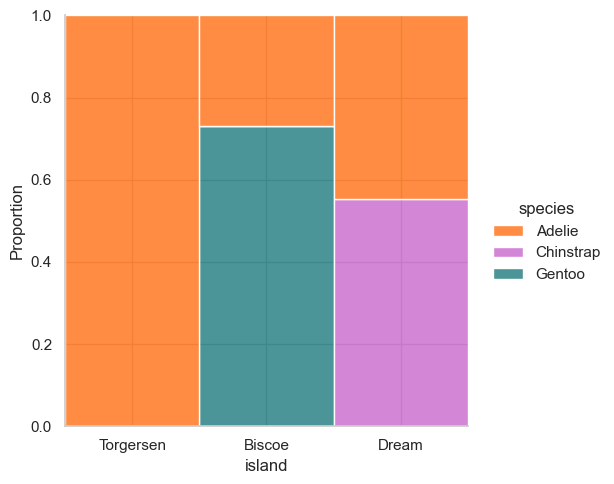

In [120]:
df.pipe(
    lambda df: (
        sns.displot(
            data=df,  # data
            x='island',  # x-axis
            hue='species',
            multiple='fill',
            palette=penguin_color,
            stat='proportion'
        )
    )
)

# Medidas de tendencia central

## Media o promedio

In [121]:
df['bill_depth_mm'].mean()

17.164864864864864

In [122]:
np.mean(df['bill_depth_mm'])

17.164864864864864

In [123]:
df.mean()

C:\Users\Yrrrrrf\AppData\Local\Temp\ipykernel_10184\3698961737.py:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.mean()


bill_length_mm         43.992793
bill_depth_mm          17.164865
flipper_length_mm     200.966967
body_mass_g          4207.057057
dtype: float64

## Mediana

In [124]:
df.median()  # mid value

C:\Users\Yrrrrrf\AppData\Local\Temp\ipykernel_10184\1737011397.py:1: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.median()  # mid value


bill_length_mm         44.5
bill_depth_mm          17.3
flipper_length_mm     197.0
body_mass_g          4050.0
dtype: float64

## Moda

In [125]:
df.mode()  # most frequent value

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Biscoe,41.1,17.0,190.0,3800.0,Male


In [126]:
df.describe(include=[object])  # descriptive statistics for categorical variables

,species,island,sex
count,333,333,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,146,163,168


# Medidas de dispersión

## ¿Cuál es el valor máximo de las variables?

In [127]:
# get max value
df.max()

species                 Gentoo
island               Torgersen
bill_length_mm            59.6
bill_depth_mm             21.5
flipper_length_mm        231.0
body_mass_g             6300.0
sex                       Male
dtype: object

## ¿Cuál es el valor mínimo de las variables?

In [128]:
df.min()

species              Adelie
island               Biscoe
bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
sex                  Female
dtype: object

## ¿Cuál es el rango de las variables?

In [129]:
df.max(numeric_only=True) - df.min(numeric_only=True)  # range

bill_length_mm         27.5
bill_depth_mm           8.4
flipper_length_mm      59.0
body_mass_g          3600.0
dtype: float64

## ¿Cuál es la desviación estándar de las variables?

In [130]:
std: float = df['body_mass_g'].std(numeric_only=True)  # standard deviation
low_lim = df['body_mass_g'].mean(numeric_only=True)
max_lim = df['body_mass_g'].mean(numeric_only=True)

print(f'65% of the data = [{low_lim - 1 * std:.4f}, {max_lim + 1 * std:.4f}]')  # mean ± std
print(f'95% of the data = [{low_lim - 2 * std:.4f}, {max_lim + 2 * std:.4f}]')  # mean ± 2 * std
print(f'99% of the data = [{low_lim - 3 * std:.4f}, {max_lim + 3 * std:.4f}]')  # mean ± 3 * std

65% of the data = [3401.8413, 5012.2729]
95% of the data = [2596.6255, 5817.4887]
99% of the data = [1791.4097, 6622.7045]


In [131]:
# sns.scatterplot(
#     x=x,
#     y=y
# )

# plt.plot(fx_1, fy_1)
# plt.plot(fy_2, fx_2)

## ¿Cuál es el rango intercuartílico?

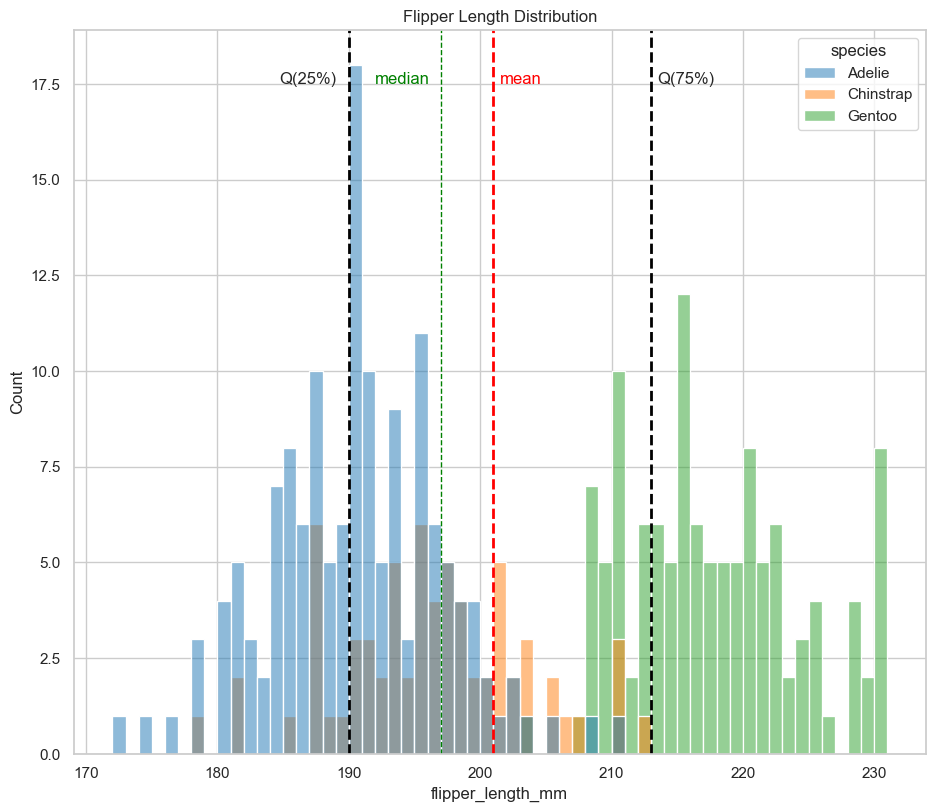

In [132]:
var_flipper_len = df['flipper_length_mm']  # flipper length (mm)

g: sns.FacetGrid = sns.histplot(
    data=df,
    x='flipper_length_mm',
    binwidth=1,
    hue='species',
    alpha=.5,
)
g.set(title='Flipper Length Distribution')  # set g title

# Add Q_25, Q_75, median, mean
plt.axvline(x =var_flipper_len.mean(), linestyle="dashed", color="r", linewidth=2)  # Mean(Red)
plt.text(201.5,17.5, 'mean', fontsize=12, color='r')
plt.axvline(x=var_flipper_len.median(), linestyle="dashed", color="g", linewidth=1)  # Median(Green)
plt.text(192,17.5, 'median', fontsize=12, color='g')
plt.axvline(x=var_flipper_len.quantile(0.75), linestyle="dashed", color="k", linewidth=2)  # Q_75(Black)
plt.text(213.5,17.5, 'Q(75%)', fontsize=12)
plt.axvline(x=var_flipper_len.quantile(0.25), linestyle="dashed", color="k", linewidth=2)  # Q_25(Black)
plt.text(184.7,17.5, 'Q(25%)', fontsize=12)

plt.show()

### Limitaciones

In [133]:
def freedman_diaconis_bindwidth(x: pd.Series) -> float:
    """Find optimal bindwidth using Freedman-Diaconis rule."""

    IQR = x.quantile(0.75) - x.quantile(0.25)
    N = x.size

    return 2 * IQR / N ** (1 / 3)

# Distribuciones: PMFs, CDFs y PDFs


## Funciones de probabilidad de masas (PMFs)

### Utilizando `seaborn`

<AxesSubplot: xlabel='flipper_length_mm', ylabel='Probability'>

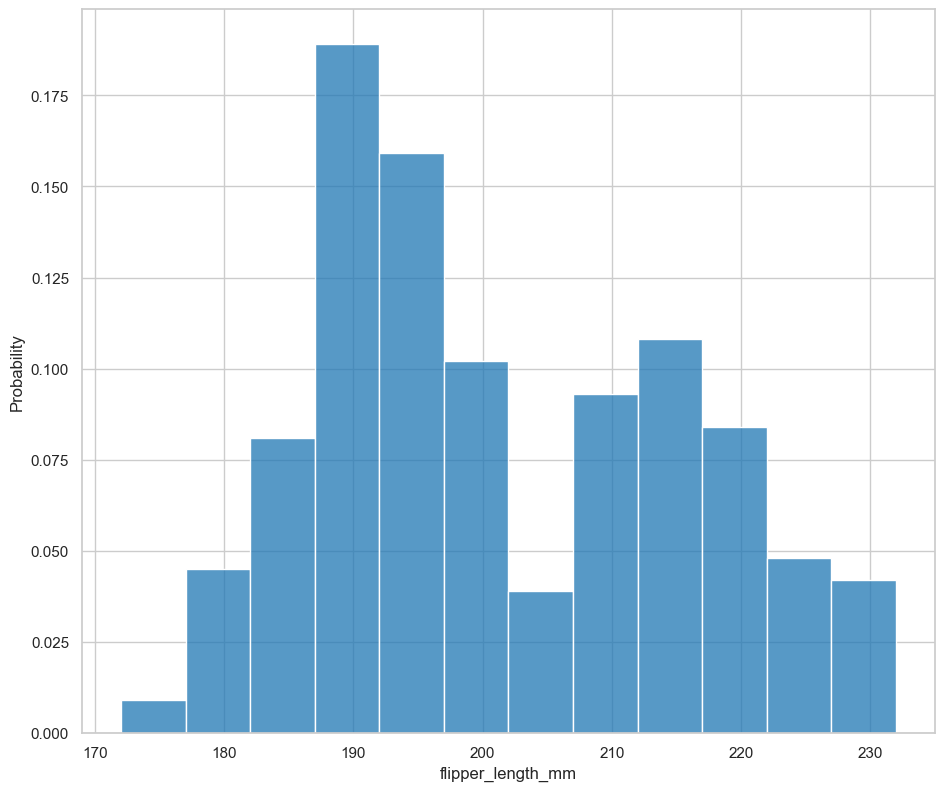

In [134]:
sns.histplot(
    data=df,
    x='flipper_length_mm',
    binwidth=5,
    stat='probability'
)

### Utilizando `empiricaldist`

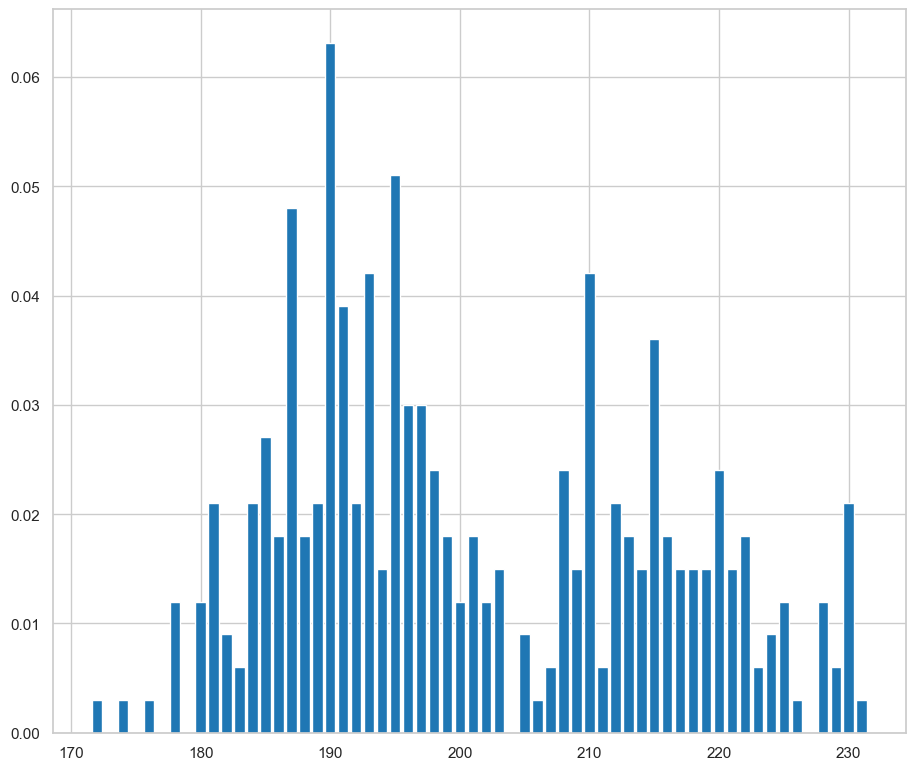

In [135]:
cdf: empiricaldist.Pmf = empiricaldist.Pmf.from_seq(df['flipper_length_mm'])  # create a CDF object (cumulative distribution function)
cdf.bar()

In [136]:
height: int = 190
print(f'Probability of a flipper length of {height} mm = {cdf(height):.2f}')

Probability of a flipper length of 190 mm = 0.06


In [137]:
print(f'Mean = {cdf.mean():.2f}')  # mean
print(f'Median = {cdf.median():.2f}')  # median
print(f'Mode = {cdf.max_prob():.2f}')  # mode

print(f'Max value = {cdf.max()}')
print(f'Min value = {cdf.min()}')
print(f'Range = {cdf.max() - cdf.min()}')

print(f'Variance = {cdf.var():.2f}')
print(f'Standard deviation = {cdf.std():.2f}')

Mean = 200.97
Median = 197.00
Mode = 190.00
Max value = 0.06306306306306306
Min value = 0.003003003003003003
Range = 0.06006006006006005
Variance = 195.85
Standard deviation = 13.99


In [138]:
print(cdf.credible_interval(0.65))  # 99.9% confidence interval
print(cdf.credible_interval(0.95))  # 95% confidence interval
print(cdf.credible_interval(0.99))  # 99% confidence interval

[187. 216.]
[180. 229.]
[174. 230.]


## Funciones empirícas de probabilidad acumulada (ECDFs)

### Utilizando `seaborn`

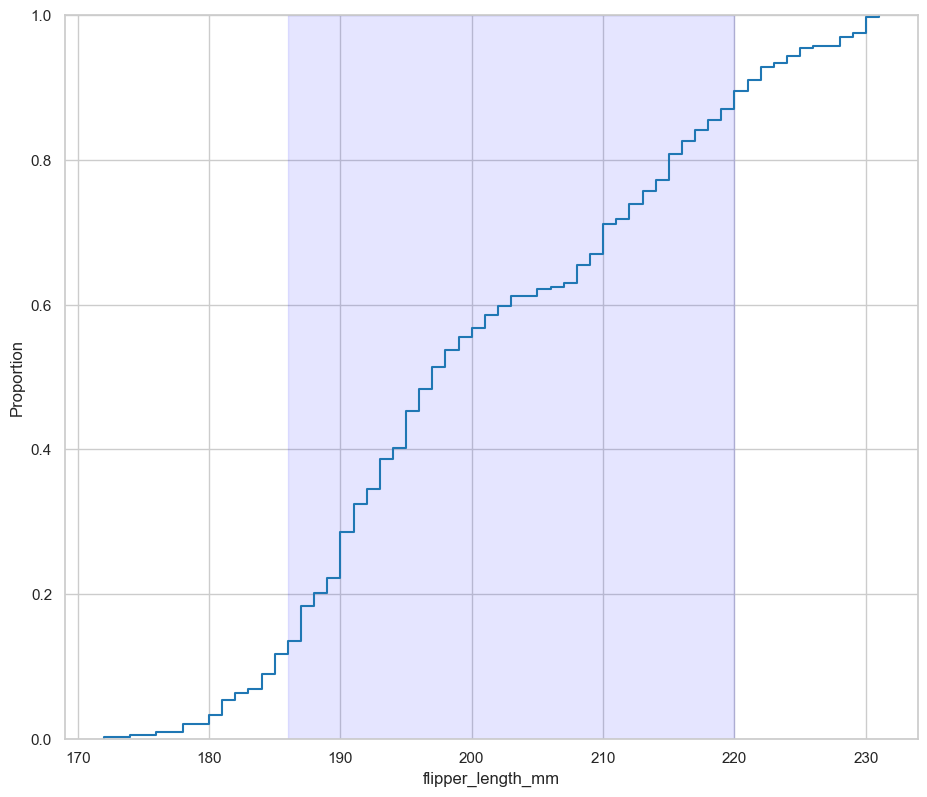

In [139]:
sns.ecdfplot(data=df, x='flipper_length_mm')

plt.axvspan(  # add a rectangle in the 25% - 75% interval
    xmin=cdf.credible_interval(0.75)[0],
    xmax=cdf.credible_interval(0.75)[1],
    color='blue',
    alpha=0.1
)


### Utilizando `empiricaldist`

25% percentile = 190
75% percentile = 213


<AxesSubplot: >

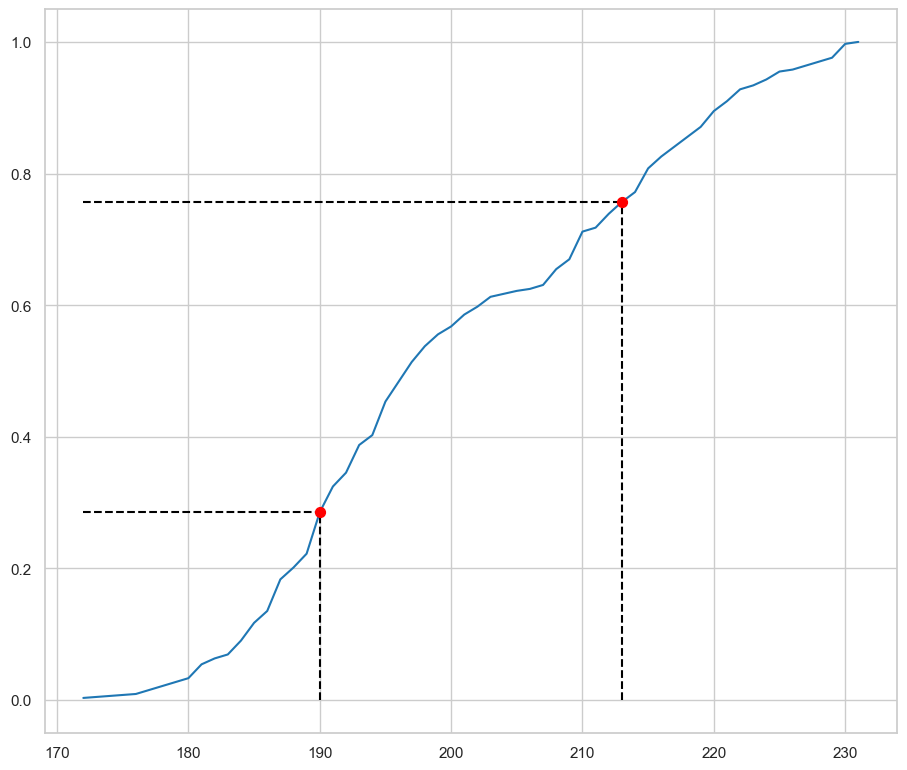

In [140]:
ecdf: empiricaldist.Cdf = empiricaldist.Cdf.from_seq(df['flipper_length_mm'])  # create a CDF object (cumulative distribution function)

for p in [0.25, 0.75]:
    print(f'{p * 100:.0f}% percentile = {ecdf.inverse(p):.0f}')
    q: int = ecdf.inverse(p)
    p: float = ecdf.forward(q)
    plt.vlines(x=q, ymin=0, ymax=p, color='black', linestyle='--')
    plt.hlines(y=p, xmin=ecdf.qs[0], xmax=q, color='black', linestyle='--')
    plt.scatter(x=q, y=p, color='red', s=50, zorder=3)

ecdf.plot()

### Comparando distribuciones

<AxesSubplot: xlabel='flipper_length_mm', ylabel='Proportion'>

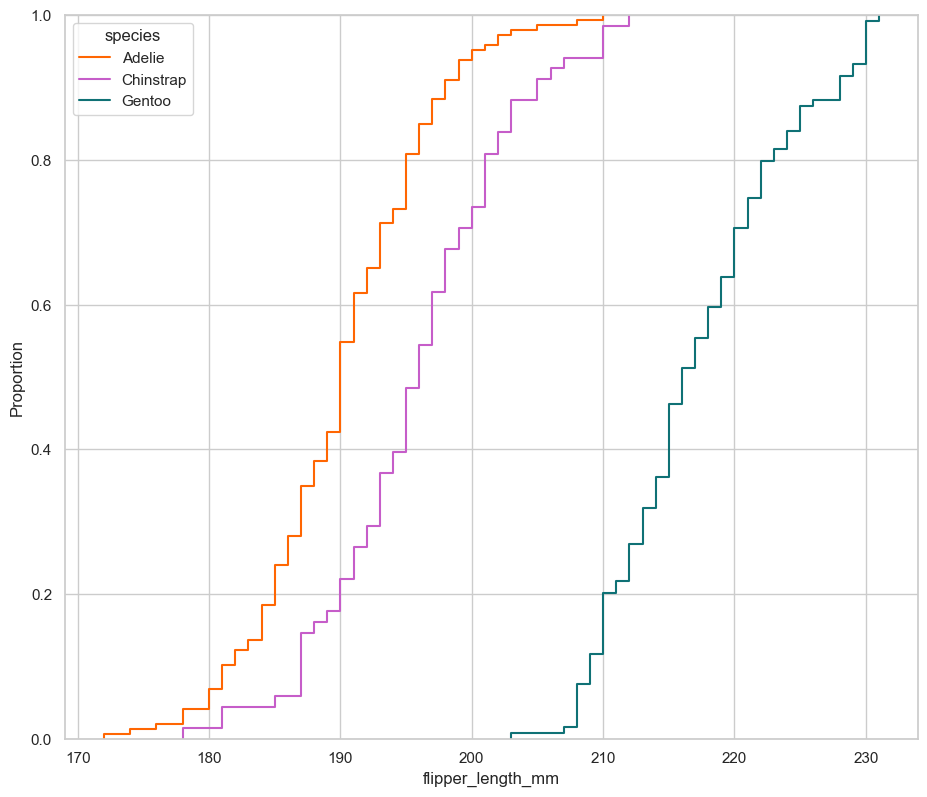

In [141]:
sns.ecdfplot(
    data=df,
    x='flipper_length_mm',
    hue='species',
    palette=penguin_color
    )

## Funciones de densidad de probabilidad

<AxesSubplot: xlabel='flipper_length_mm', ylabel='Density'>

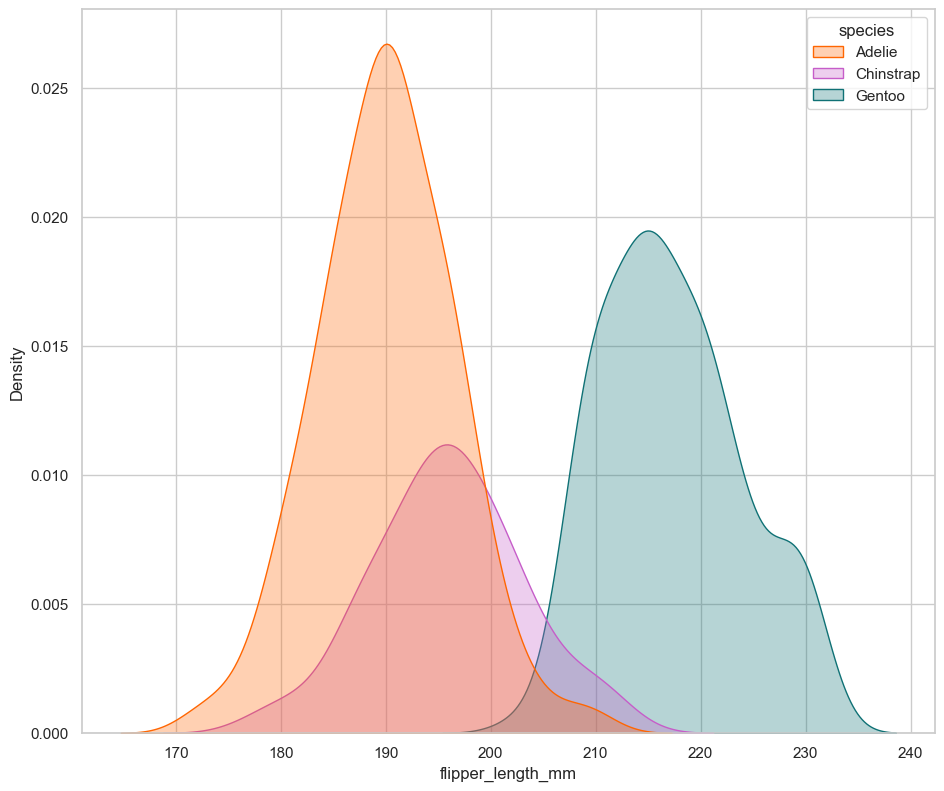

In [142]:
sns.kdeplot(data=df, x='flipper_length_mm', hue='species', palette=penguin_color, fill=True, alpha=.3)

In [143]:
stats = df['body_mass_g'].describe()
print(stats)

count     333.000000
mean     4207.057057
std       805.215802
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4775.000000
max      6300.000000
Name: body_mass_g, dtype: float64


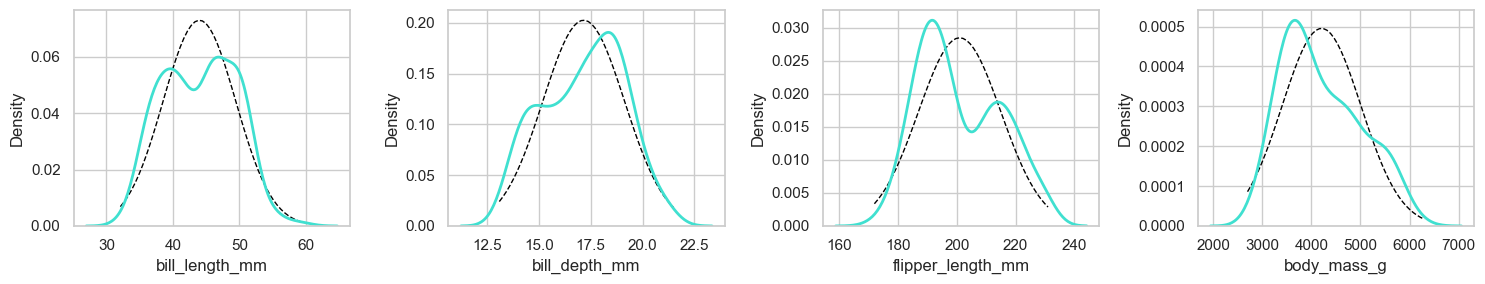

In [144]:
# cdf = ys.cdf(xs)  # Cumulative Distribution Function (CDF)

# plt.plot(xs, cdf, label='CDF', color='black', linestyle='--')  # plot CDF

medida=df.select_dtypes('float64').columns
fig,ax=plt.subplots(1,4,figsize=(15,3))
for i ,value in enumerate(medida) :
    stats=df[value].describe()
    xs=np.linspace(stats['min'],stats['max'])
    ys=scipy.stats.norm(stats['mean'],stats['std']).pdf(xs)  # Probability Density Function (PDF)
    ax[i].plot(xs,ys,color='black',linestyle='--', linewidth=1)  # plot PDF
    sns.kdeplot(  # plot real data
        ax=ax[i],  # plot on the same axis
        data=df,  # data
        x=value,  # variable
        color='turquoise',  # color
        linewidth=2,  # line width
    )
fig.tight_layout()

# Ley de los Grandes Números y Teorema del Límite Central

## Ley de los Grandes Números

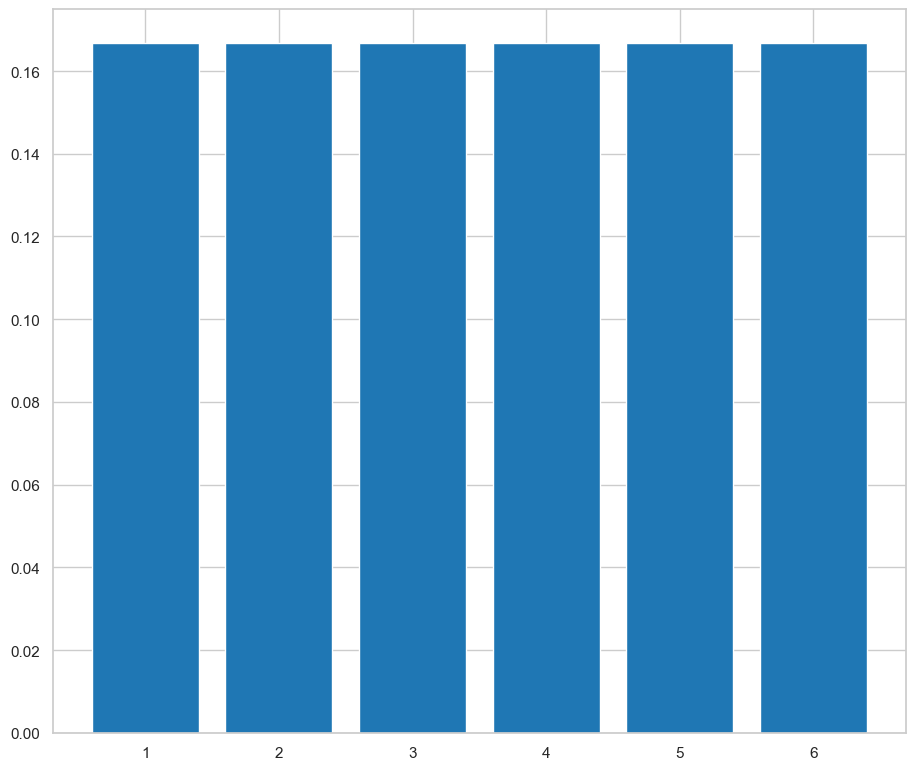

In [145]:
dice = empiricaldist.Pmf.from_seq([1,2,3,4,5,6])
dice.bar()

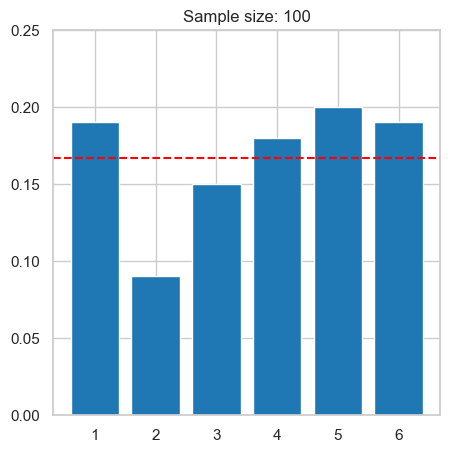

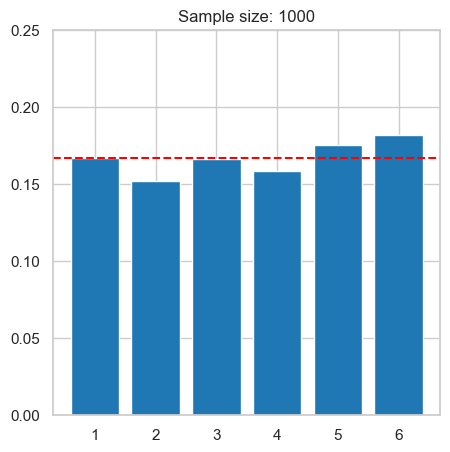

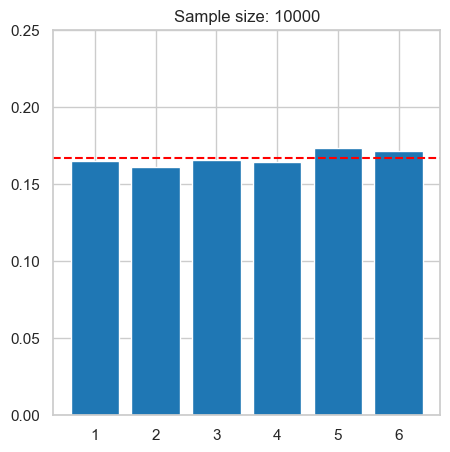

In [146]:
for sample_size in (1e2, 1e3,1e4):
    sample_size = int(sample_size)
    sample_pmf = empiricaldist.Pmf.from_seq(dice.sample(sample_size))  # get the probability mass function

    plt.figure(figsize=(5, 5))  # set the figure size
    sample_pmf.bar()  # plot the sample PMF

    plt.axhline(y=1/6, color='r', linestyle='--')  # add a horizontal line
    plt.ylim([0,0.25])  # set the y-axis limit
    plt.title(f'Sample size: {sample_size}')  # set the title

## Teorema del Límite Central

In [147]:
df['sex'].value_counts(normalize=True)  # get the proportion of each category

Male      0.504505
Female    0.495495
Name: sex, dtype: float64

In [148]:
numeric_sex = df['sex'].replace(['Male', 'Female'], [1, 0])  # replace the categorical values with numeric values)

In [154]:
number_samples = 1000  # random samples
sample_size = 35  # sample size

samples_df: pd.DataFrame = pd.DataFrame()  # create an empty dataframe

for i in range(1, number_samples + 1):
    sex_numeric_sample = numeric_sex.sample(sample_size, replace=True).to_numpy()  # get a random sample
    sample_name = f"sample_{i}"  # name of the sample
    samples_df[sample_name] = sex_numeric_sample  # add the sample to the dataframe

male_population_mean = samples_df.mean().mean()  # get the mean of the sample means
print(f"Estimated percentage of male penguins in population is: {male_population_mean * 100:.4f}%")

C:\Users\Yrrrrrf\AppData\Local\Temp\ipykernel_10184\2960963317.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  samples_df[sample_name] = sex_numeric_sample  # add the sample to the dataframe
C:\Users\Yrrrrrf\AppData\Local\Temp\ipykernel_10184\2960963317.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  samples_df[sample_name] = sex_numeric_sample  # add the sample to the dataframe
C:\Users\Yrrrrrf\AppData\Local\Temp\ipykernel_10184\2960963317.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

Estimated percentage of male penguins in population is: 50.3771%


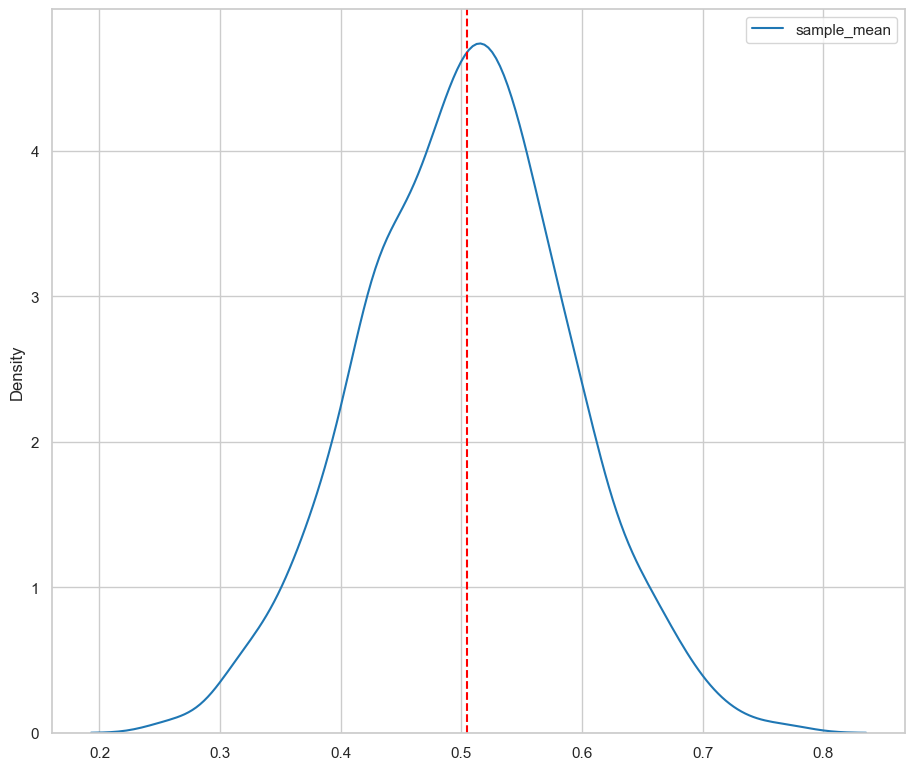

In [155]:
sample_means_binomial = pd.DataFrame(samples_df.mean(), columns=['sample_mean'])
sns.kdeplot(data=sample_means_binomial)
plt.axvline(x=numeric_sex.mean(), color='red', linestyle='dashed')

In [156]:
sample_size_experiment = pd.DataFrame(
    [[i, samples_df.iloc[:, 0:i].mean().mean().mean()] for i in range(1, number_samples + 1)],
    columns=['sample_size', 'estimated_mean']
)

(0.30450450450450445, 0.7045045045045044)

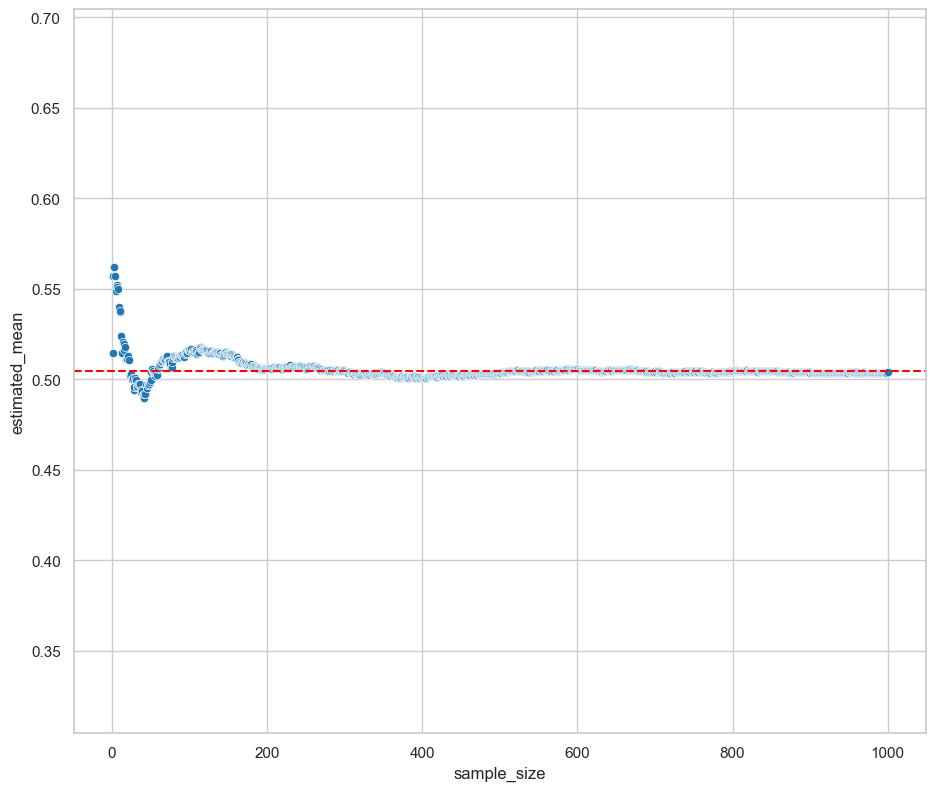

In [157]:
sns.scatterplot(
    data=sample_size_experiment,
    x='sample_size',
    y='estimated_mean'
)

plt.axhline(
    y=numeric_sex.mean(),
    color='red',
    linestyle='dashed'
)

plt.ylim([numeric_sex.mean() - 0.20, numeric_sex.mean() + 0.20])

# Estableciendo relaciones: Gráfica de puntos

# Estableciendo relaciones: Gráficos de violín y boxplots

# Estableciendo relaciones: Matrices de correlación

## ¿Existe una correlación lineal entre alguna de nuestras variables?

## ¿Cómo puedo visualizar los coeficientes de correlación?

## ¿Cómo podría representar una variable categórica como númerica discreta?

## ¿Cuál es una limitante de los coeficientes de correlación lineal?

### Solo nos ayuda a determinar la posible existencia de una correlación lineal; sin embargo, su ausenecia no significa que no exista otro tipo de correlación

### El coeficiente de correlación no nos habla del impacto de la relación

# Estableciendo relaciones: Análisis de regresión simple

# Limitaciones del análisis de regresión simple

## La regresión lineal simple no es simétrica

## La regresión no nos dice nada sobre la causalidad, pero existen herramientas para separar las relaciones entre múltiples variables

# Análisis de regresión múltiple

## Olvidé mi báscula para pesar a los pingüinos, ¿cuál sería la mejor forma de capturar ese dato?

### Creando modelos

#### Modelo 1

#### Modelo 2

#### Modelo 3

#### Modelo 4

#### Modelo 5

### Visualizando resultados

#### Creación de tabla de resultados

#### ECDFs

#### PDFs

#### ¿Qué pudimos haber encontrado antes de hacer los modelos?

# Análisis de regresión logística

## ¿Podemos crear un modelo que nos ayude a definir si un pingüino es macho o hembra?

## Exploración de nuestras variables categóricas

## ¿Podemos definir un modelo que nos ayude a identificar si un pingüino pertenece a determinada clase?

# Paradoja de Simpson

## Información de sesión

In [ ]:
# session_info.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=48ec5318-04ba-4e24-80f3-2af0a1b140d1' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>